# Notebook 07 Stronger classifiers for BTC direction (regime-aware)

## Purpose
Build the strongest non-sequence model we can for the **same supervised task as notebook 04**, and quantify how much the regime context from notebook 05 (K-Means) and notebook 06 (HMM) actually contributes. We additionally sweep the HMM state count $K \in \{2, 3, 4\}$ to ask whether a different regime granularity than the one BIC chose in 06 is more useful for downstream prediction.

## Task
Binary classification of the **sign of BTC's average log return over the next 30 trading days**:

- `target = 1` if `mean(BTC_log_return[t+1 : t+30]) > 0`, else `0`
- Horizon: 30 trading days forward (NOT next-day)
- Target built strictly forward-looking; `build_forward_target` is copied verbatim from 04 so the test set aligns with `baseline_predictions.csv`

## Data inputs
- `data/processed/crypto_wide_log_returns_aligned.csv` BTC log returns
- `data/processed/crypto_features_long_aligned.csv` per-asset features, aggregated daily via the same `build_daily_market_features` function used in 05/06
- `data/processed/regime_labels_baseline.csv` K-Means hard regime label (from 05)
- `data/model_outputs/hmm_regime_labels_k{2,3,4}.csv` HMM hard label + posteriors for each $K$ (from 06's per-K save section)
- `data/model_outputs/baseline_predictions.csv` 04 baselines on the test set, used for direct delta comparison

## Split
Chronological 80/20 first 80% train, last 20% test. No shuffling. `StandardScaler` fit on train only.

## Feature blocks (used as ablations, per $K$)
1. **base** — 9 base features (returns, dispersion, vol, BTC-corr, idio vol, 4 macro)
2. **base+kmeans** — base + K-Means one-hot
3. **base+hmm** — base + HMM one-hot + HMM posteriors (for the current $K$)
4. **base+kmeans+hmm** — combined regime context

For each $K \in \{2, 3, 4\}$ the four blocks are constructed independently — the HMM-related columns differ by $K$.

## Models
1. Logistic Regression (L2) — interpretable reference
2. Random Forest — non-linear, handles interactions
3. Gradient Boosting (sklearn) — typically strongest tabular baseline

(K × model × feature_block) = **36 MLflow runs** under `EXPERIMENT_CLASSIFIERS`. Each run logs `k_states`, `model_type`, `feature_block` as parameters.

## Evaluation (per run + best run)
- Accuracy, F1 macro, precision, recall on the held-out test set
- Confusion matrix (best run only)
- Cumulative log-return backtest (long BTC when pred=1, cash when pred=0) vs buy-and-hold BTC
- **Per-regime stratified metrics**, using the best $K$'s HMM regime labels
- Feature importance (best run only)

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix,
)

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_CLASSIFIERS
from src.utils.plot_config import COIN_COLORS, apply_plot_style

warnings.filterwarnings("ignore")
apply_plot_style()
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

get_or_create_experiment(EXPERIMENT_CLASSIFIERS)
mlflow.set_experiment(EXPERIMENT_CLASSIFIERS)

<Experiment: artifact_location='file:///C:/Users/taula/Github/HSLU/DSPRO2/HSLU_FS25_DSPRO2/mlruns/382878479472838162', creation_time=1777715528913, experiment_id='382878479472838162', last_update_time=1777715528913, lifecycle_stage='active', name='classification', tags={}>

## Configuration

`HORIZON` and `TEST_FRACTION` mirror notebook 04 so the test set aligns with `baseline_predictions.csv`. `K_VALUES` is the HMM state-count sweep we run downstream.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

# Inputs
LOG_RETURNS_PATH   = DATA_PROCESSED_DIR / "crypto_wide_log_returns_aligned.csv"
FEATURES_LONG_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"
KMEANS_PATH        = DATA_PROCESSED_DIR / "regime_labels_baseline.csv"
BASELINE_PATH      = DATA_MODEL_OUTPUTS_DIR / "baseline_predictions.csv"

K_VALUES = [2, 3, 4]
HMM_PATHS = {k: DATA_MODEL_OUTPUTS_DIR / f"hmm_regime_labels_k{k}.csv" for k in K_VALUES}

# Output
PREDICTIONS_OUTPUT_PATH = DATA_MODEL_OUTPUTS_DIR / "classification_predictions.csv"

HORIZON = 30
TEST_FRACTION = 0.2
RANDOM_STATE = 42

## Load data

In [3]:
log_returns_df = pd.read_csv(LOG_RETURNS_PATH, parse_dates=["Date"], index_col="Date")
features_long_df = pd.read_csv(FEATURES_LONG_PATH, parse_dates=["Date"])
kmeans_df = pd.read_csv(KMEANS_PATH, parse_dates=["Date"], index_col="Date")
baselines_df = pd.read_csv(BASELINE_PATH, parse_dates=["Date"], index_col="Date")

hmm_dfs = {k: pd.read_csv(p, parse_dates=["Date"], index_col="Date") for k, p in HMM_PATHS.items()}

print("Log returns:", log_returns_df.shape)
print("Features long:", features_long_df.shape)
print("K-Means labels:", kmeans_df.shape)
print("Baseline preds:", baselines_df.shape)
for k, df in hmm_dfs.items():
    print(f"HMM K={k}: {df.shape}  cols={list(df.columns)}")

Log returns: (2174, 6)
Features long: (13044, 15)
K-Means labels: (2144, 1)
Baseline preds: (429, 4)
HMM K=2: (2144, 3)  cols=['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1']
HMM K=3: (2144, 4)  cols=['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']
HMM K=4: (2144, 5)  cols=['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2', 'hmm_prob_state_3']


## Build daily market features

Same aggregation function as in 05/06 to keep the feature space consistent across the project.

In [ ]:
from src.features.daily import build_daily_market_features

daily_df = build_daily_market_features(features_long_df).dropna()
print("Daily features:", daily_df.shape)

## Build the prediction target

Same construction as notebook 04: sign of BTC's average log return over the next 30 trading days. Strictly forward-looking uses returns from $t+1$ to $t+30$ only.

In [5]:
def build_forward_target(btc_returns: pd.Series, horizon: int) -> pd.Series:
    """Sign of BTC's mean log return over the next `horizon` days. Verbatim from 04."""
    forward_avg = btc_returns.shift(-1).rolling(window=horizon).mean().shift(-(horizon - 1))
    return (forward_avg > 0).astype("Int64")

btc_returns = log_returns_df["BTC"]
target = build_forward_target(btc_returns, HORIZON).rename("target")

print("Target class balance (incl. NaN-coerced tail):")
print(target.value_counts(dropna=False))

Target class balance (incl. NaN-coerced tail):
target
1    1168
0    1006
Name: count, dtype: Int64


## Merge regime sources for all $K$

K-Means hard label and each HMM hard label are one-hot encoded. HMM posteriors are kept as continuous features. To avoid column-name collisions across $K$ values, the HMM columns are prefixed with `hmm_k{K}_`.

In [6]:
# K-Means: one-hot
kmeans_oh = pd.get_dummies(kmeans_df["regime"], prefix="kmeans_state").astype(int)

# HMM: per-K one-hot of hard label + posterior probabilities, all prefixed with hmm_k{K}_
hmm_blocks = {}
hmm_hard_cols = {}   # K -> name of the hard-label column kept in `data` for stratification
for k, hdf in hmm_dfs.items():
    oh = pd.get_dummies(hdf["hmm_regime"], prefix=f"hmm_k{k}_state").astype(int)
    post_cols = [c for c in hdf.columns if c.startswith("hmm_prob_state_")]
    post = hdf[post_cols].rename(columns={c: f"hmm_k{k}_prob_state_{c.split('_')[-1]}" for c in post_cols})
    hard_col = f"hmm_k{k}_regime"
    hard = hdf["hmm_regime"].rename(hard_col)
    hmm_blocks[k] = pd.concat([oh, post], axis=1)
    hmm_hard_cols[k] = hard_col
    # Also stash hard label as a plain column for later stratification
    hmm_blocks[k][hard_col] = hard

# Join everything
data = daily_df.join(kmeans_oh, how="inner")
for k in K_VALUES:
    data = data.join(hmm_blocks[k], how="inner")
data = data.join(target, how="inner")

# Keep K-Means hard label too
data["kmeans_regime"] = kmeans_df["regime"]

# Drop rows with NaN in base features
data = data.dropna(subset=daily_df.columns.tolist())
data["target"] = data["target"].astype(int)

print("Final dataset:", data.shape)
print("Date range:", data.index.min().date(), "to", data.index.max().date())

Final dataset: (2144, 34)
Date range: 2020-05-10 to 2026-03-23


## Feature blocks per $K$

Four blocks per $K$ base only, base + each regime source separately, and base + both. The HMM block contents change with $K$; the base and K-Means blocks are identical across $K$.

In [7]:
BASE_FEATURES = [
    "mean_log_return", "return_dispersion", "mean_volatility",
    "mean_btc_corr", "mean_idio_vol",
    "dxy_log_return", "gold_log_return", "sp500_log_return", "vix_log_return",
]
KMEANS_FEATURES = [c for c in data.columns if c.startswith("kmeans_state_")]

def hmm_features_for(k: int) -> list:
    return [c for c in data.columns if c.startswith(f"hmm_k{k}_state_") or c.startswith(f"hmm_k{k}_prob_state_")]

FEATURE_BLOCKS = {}
for k in K_VALUES:
    hmm_feats = hmm_features_for(k)
    FEATURE_BLOCKS[k] = {
        "base":             BASE_FEATURES,
        "base+kmeans":      BASE_FEATURES + KMEANS_FEATURES,
        "base+hmm":         BASE_FEATURES + hmm_feats,
        "base+kmeans+hmm":  BASE_FEATURES + KMEANS_FEATURES + hmm_feats,
    }
    for name, cols in FEATURE_BLOCKS[k].items():
        print(f"K={k}  {name:20s} {len(cols)} features")
    print()

K=2  base                 9 features
K=2  base+kmeans          11 features
K=2  base+hmm             13 features
K=2  base+kmeans+hmm      15 features

K=3  base                 9 features
K=3  base+kmeans          11 features
K=3  base+hmm             15 features
K=3  base+kmeans+hmm      17 features

K=4  base                 9 features
K=4  base+kmeans          11 features
K=4  base+hmm             17 features
K=4  base+kmeans+hmm      19 features



## Chronological train/test split

First 80% of dates train, last 20% test. Same split fraction as 04 test set aligns with `baseline_predictions.csv`

In [8]:
split_idx = int(len(data) * (1 - TEST_FRACTION))
train_data = data.iloc[:split_idx]
test_data = data.iloc[split_idx:]

y_train = train_data["target"]
y_test = test_data["target"]

print(f"Train: {len(train_data)} rows | {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Test:  {len(test_data)} rows | {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"\nTest class balance:\n{y_test.value_counts().sort_index()}")

Train: 1715 rows | 2020-05-10 to 2025-01-18
Test:  429 rows | 2025-01-19 to 2026-03-23

Test class balance:
target
0    257
1    172
Name: count, dtype: int64


## Train ablation matrix (3 K × 3 models × 4 feature blocks = 36 runs)

Each combination is one MLflow run tagged with `k_states`, `model_type`, and `feature_block`. Logistic regression uses scaled features; tree models use raw values.

In [9]:
def make_models():
    return {
        "logreg": LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
        "rf":     RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
        "gbm":    GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    }

results = []
trained = {}  # (k, model_name, block_name) -> dict with model, scaler, preds, proba, feat_cols

for k in K_VALUES:
    for block_name, feat_cols in FEATURE_BLOCKS[k].items():
        X_train = train_data[feat_cols]
        X_test  = test_data[feat_cols]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s  = scaler.transform(X_test)

        for model_name, model in make_models().items():
            run_name = f"{model_name}_{block_name}_k{k}"
            with mlflow.start_run(run_name=run_name):
                if model_name == "logreg":
                    model.fit(X_train_s, y_train)
                    preds = model.predict(X_test_s)
                    proba = model.predict_proba(X_test_s)[:, 1]
                else:
                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    proba = model.predict_proba(X_test)[:, 1]

                metrics = {
                    "accuracy": accuracy_score(y_test, preds),
                    "f1_macro": f1_score(y_test, preds, average="macro"),
                    "precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
                    "recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
                }

                mlflow.log_params({
                    "model_type": model_name,
                    "feature_block": block_name,
                    "k_states": k,
                    "n_features": len(feat_cols),
                    "task": "btc_30d_avg_return_sign",
                    "horizon": HORIZON,
                    "scaling": "StandardScaler" if model_name == "logreg" else "none",
                })
                mlflow.log_metrics(metrics)

                results.append({"k": k, "model": model_name, "block": block_name, **metrics})
                trained[(k, model_name, block_name)] = {
                    "model": model,
                    "scaler": scaler,
                    "preds": preds,
                    "proba": proba,
                    "feat_cols": feat_cols,
                }

results_df = pd.DataFrame(results).set_index(["k", "model", "block"]).sort_values("f1_macro", ascending=False)
print(f"Total runs: {len(results)}")
print("\nTop 10 by F1 macro:")
results_df.head(10).round(4)

Total runs: 36

Top 10 by F1 macro:


accuracy  f1_macro  precision_macro  recall_macro
k model  block                                                             
2 rf     base+hmm           0.4848    0.4746           0.5417        0.5335
         base+kmeans+hmm    0.4709    0.4564           0.5315        0.5238
4 logreg base+hmm           0.4592    0.4537           0.4984        0.4986
2 gbm    base+kmeans+hmm    0.4592    0.4502           0.5053        0.5044
         base+hmm           0.4569    0.4488           0.5006        0.5005
4 logreg base+kmeans+hmm    0.4452    0.4373           0.4857        0.4879
  rf     base+hmm           0.4499    0.4370           0.4994        0.4995
3 rf     base+kmeans+hmm    0.4499    0.4370           0.4994        0.4995
  gbm    base               0.4429    0.4364           0.4804        0.4831
4 gbm    base               0.4429    0.4364           0.4804        0.4831

Three small heatmaps (one per $K$) so the ablation is readable at a glance.

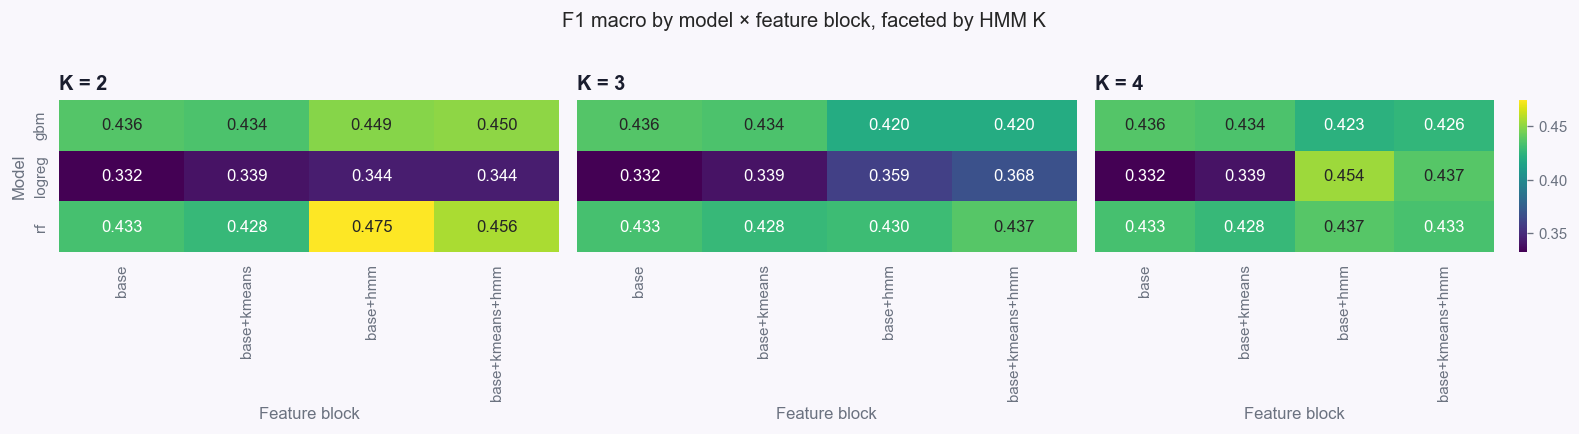

In [10]:
fig, axes = plt.subplots(1, len(K_VALUES), figsize=(4.5 * len(K_VALUES), 3.5), sharey=True)
if len(K_VALUES) == 1:
    axes = [axes]

block_order = ["base", "base+kmeans", "base+hmm", "base+kmeans+hmm"]
for ax, k in zip(axes, K_VALUES):
    sub = results_df.xs(k, level="k").reset_index()
    pivot = sub.pivot(index="model", columns="block", values="f1_macro")[block_order]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis",
                vmin=results_df["f1_macro"].min(), vmax=results_df["f1_macro"].max(),
                ax=ax, cbar=(ax is axes[-1]))
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Feature block")
    ax.set_ylabel("Model" if ax is axes[0] else "")

plt.suptitle("F1 macro by model × feature block, faceted by HMM K", y=1.02)
plt.tight_layout()
plt.show()

How does the choice of $K$ affect the best achievable F1, holding model and block fixed? This view marginalizes over models to show whether more states genuinely help.

In [11]:
# Best F1 per (k, block), averaged over models
by_k_block = results_df.reset_index().groupby(["k", "block"])["f1_macro"].max().unstack("k")
by_k_block.round(4)

k,2,3,4
block,,,
base,0.4364,0.4364,0.4364
base+hmm,0.4746,0.4295,0.4537
base+kmeans,0.4343,0.4343,0.4343
base+kmeans+hmm,0.4564,0.4370,0.4373


## Comparison vs notebook 04 baselines

Align test dates and report `(07 model − each baseline)` deltas.

In [12]:
baselines_aligned = baselines_df.loc[y_test.index]
assert (baselines_aligned["y_true"].to_numpy() == y_test.to_numpy()).all(), \
    "Test labels disagree with baseline_predictions — split or target may have drifted from 04."

baseline_metrics = {}
for col in ["majority_class", "persistence_momentum", "logistic_regression"]:
    baseline_metrics[col] = {
        "accuracy": accuracy_score(y_test, baselines_aligned[col]),
        "f1_macro": f1_score(y_test, baselines_aligned[col], average="macro"),
    }
baseline_summary = pd.DataFrame(baseline_metrics).T
print("04 baselines on the same test set:")
print(baseline_summary.round(4))

04 baselines on the same test set:
                      accuracy  f1_macro
majority_class          0.4009    0.2862
persistence_momentum    0.5012    0.4902
logistic_regression     0.4056    0.3551


In [13]:
# Build delta table: each (k, model, block) vs each baseline. Sort by F1 macro.
delta_rows = []
for (k, model_name, block_name), info in trained.items():
    acc = accuracy_score(y_test, info["preds"])
    f1  = f1_score(y_test, info["preds"], average="macro")
    row = {"k": k, "model": model_name, "block": block_name, "accuracy": acc, "f1_macro": f1}
    for bname, bmetrics in baseline_metrics.items():
        row[f"d_acc_vs_{bname}"] = acc - bmetrics["accuracy"]
        row[f"d_f1_vs_{bname}"]  = f1  - bmetrics["f1_macro"]
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows).set_index(["k", "model", "block"]).sort_values("f1_macro", ascending=False)
print("Top 10 by F1 macro (deltas vs 04 baselines):")
delta_df.head(10).round(4)

Top 10 by F1 macro (deltas vs 04 baselines):


accuracy  f1_macro  d_acc_vs_majority_class  \
k model  block                                                          
2 rf     base+hmm           0.4848    0.4746                   0.0839   
         base+kmeans+hmm    0.4709    0.4564                   0.0699   
4 logreg base+hmm           0.4592    0.4537                   0.0583   
2 gbm    base+kmeans+hmm    0.4592    0.4502                   0.0583   
         base+hmm           0.4569    0.4488                   0.0559   
4 logreg base+kmeans+hmm    0.4452    0.4373                   0.0443   
  rf     base+hmm           0.4499    0.4370                   0.0490   
3 rf     base+kmeans+hmm    0.4499    0.4370                   0.0490   
  gbm    base               0.4429    0.4364                   0.0420   
4 gbm    base               0.4429    0.4364                   0.0420   

                          d_f1_vs_majority_class  \
k model  block                                     
2 rf     base+hmm                         0.1884   
         base+kmeans+hmm                  0.1702   
4 logreg base+hmm                         0.1675   
2 gbm    base+kmeans+hmm                  0.1640   
         base+hmm                         0.1626   
4 logreg base+kmeans+hmm                  0.1511   
  rf     base+hmm                         0.1508   
3 rf     base+kmeans+hmm                  0.1508   
  gbm    base                             0.1502   
4 gbm    base                             0.1502   

                          d_acc_vs_persistence_momentum  \
k model  block                                            
2 rf     base+hmm                               -0.0163   
         base+kmeans+hmm                        -0.0303   
4 logreg base+hmm                               -0.0420   
2 gbm    base+kmeans+hmm                        -0.0420   
         base+hmm                               -0.0443   
4 logreg base+kmeans+hmm                        -0.0559   
  rf     base+hmm                               -0.0513   
3 rf     base+kmeans+hmm                        -0.0513   
  gbm    base                                   -0.0583   
4 gbm    base                                   -0.0583   

                          d_f1_vs_persistence_momentum  \
k model  block                                           
2 rf     base+hmm                              -0.0156   
         base+kmeans+hmm                       -0.0338   
4 logreg base+hmm                              -0.0365   
2 gbm    base+kmeans+hmm                       -0.0400   
         base+hmm                              -0.0414   
4 logreg base+kmeans+hmm                       -0.0529   
  rf     base+hmm                              -0.0532   
3 rf     base+kmeans+hmm                       -0.0532   
  gbm    base                                  -0.0538   
4 gbm    base                                  -0.0538   

                          d_acc_vs_logistic_regression  \
k model  block                                           
2 rf     base+hmm                               0.0793   
         base+kmeans+hmm                        0.0653   
4 logreg base+hmm                               0.0536   
2 gbm    base+kmeans+hmm                        0.0536   
         base+hmm                               0.0513   
4 logreg base+kmeans+hmm                        0.0396   
  rf     base+hmm                               0.0443   
3 rf     base+kmeans+hmm                        0.0443   
  gbm    base                                   0.0373   
4 gbm    base                                   0.0373   

                          d_f1_vs_logistic_regression  
k model  block                                         
2 rf     base+hmm                              0.1194  
         base+kmeans+hmm                       0.1013  
4 logreg base+hmm                              0.0986  
2 gbm    base+kmeans+hmm                       0.0950  
         base+hmm                              0.0936  
4 logreg base+kmeans+hmm     

In [14]:
# Identify the best run by F1 macro across the entire 36-run grid
best_key = max(trained.keys(), key=lambda k: f1_score(y_test, trained[k]["preds"], average="macro"))
best_k, best_model_name, best_block_name = best_key
best = trained[best_key]
best_acc = accuracy_score(y_test, best['preds'])
best_f1  = f1_score(y_test, best['preds'], average='macro')

print(f"Best run: {best_model_name}_{best_block_name}_k{best_k}")
print(f"  accuracy = {best_acc:.4f}")
print(f"  f1_macro = {best_f1:.4f}")
print("\nDelta vs strongest baseline (persistence_momentum):")
print(f"  d_accuracy = {best_acc - baseline_metrics['persistence_momentum']['accuracy']:+.4f}")
print(f"  d_f1_macro = {best_f1  - baseline_metrics['persistence_momentum']['f1_macro']:+.4f}")

Best run: rf_base+hmm_k2
  accuracy = 0.4848
  f1_macro = 0.4746

Delta vs strongest baseline (persistence_momentum):
  d_accuracy = -0.0163
  d_f1_macro = -0.0156


## Per-regime stratified metrics (best run)

Split test results by the winning $K$'s HMM regime accuracy/F1 per regime tells us whether the models edge is uniform or concentrated in particular market states.

In [15]:
best_preds = best["preds"]
regime_col = hmm_hard_cols[best_k]
test_with = test_data.assign(pred=best_preds)

per_regime = []
for regime, sub in test_with.groupby(regime_col):
    per_regime.append({
        "regime": int(regime),
        "n": len(sub),
        "accuracy": accuracy_score(sub["target"], sub["pred"]),
        "f1_macro": f1_score(sub["target"], sub["pred"], average="macro"),
        "share_positive_actual": sub["target"].mean(),
        "share_positive_pred":   sub["pred"].mean(),
    })
per_regime_df = pd.DataFrame(per_regime).set_index("regime").sort_index()
per_regime_df.round(4)

,n,accuracy,f1_macro,share_positive_actual,share_positive_pred
regime,,,,,
0,36,0.6944,0.6824,0.5556,0.6389
1,393,0.4656,0.4558,0.3868,0.7481


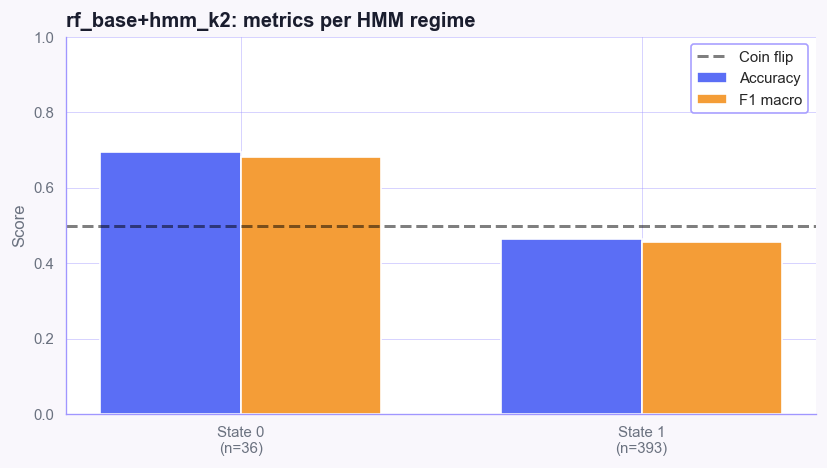

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(per_regime_df))
width = 0.35
ax.bar(x - width/2, per_regime_df["accuracy"], width, label="Accuracy", color="#5B6EF5")
ax.bar(x + width/2, per_regime_df["f1_macro"], width, label="F1 macro", color="#F49D37")
ax.axhline(0.5, color="black", linestyle="--", alpha=0.5, label="Coin flip")
ax.set_xticks(x)
ax.set_xticklabels([f"State {r}\n(n={n})" for r, n in zip(per_regime_df.index, per_regime_df['n'])])
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title(f"{best_model_name}_{best_block_name}_k{best_k}: metrics per HMM regime")
ax.legend()
plt.tight_layout()
plt.show()

## Backtest with BTC returns

Strategy: long BTC on day $t$ when the model predicts target $=1$ (BTC will be up over the next 30 days), cash otherwise. Compared to buy-and-hold BTC.

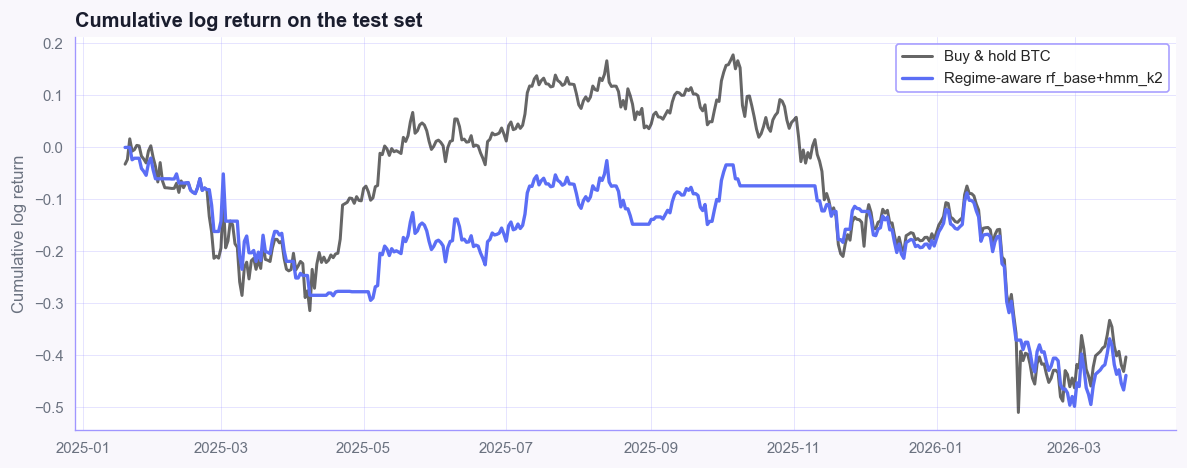

Strategy total log return: -0.4387
BTC buy & hold log return: -0.4031


In [17]:
btc_test_returns = btc_returns.loc[y_test.index]
strategy_returns = best_preds * btc_test_returns

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(btc_test_returns.cumsum(), label="Buy & hold BTC", color="black", alpha=0.6)
ax.plot(strategy_returns.cumsum(),
        label=f"Regime-aware {best_model_name}_{best_block_name}_k{best_k}",
        color="#5B6EF5", linewidth=2)
ax.set_title("Cumulative log return on the test set")
ax.set_ylabel("Cumulative log return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Strategy total log return: {strategy_returns.sum():+.4f}")
print(f"BTC buy & hold log return: {btc_test_returns.sum():+.4f}")

## Confusion matrix and feature importance (best run)

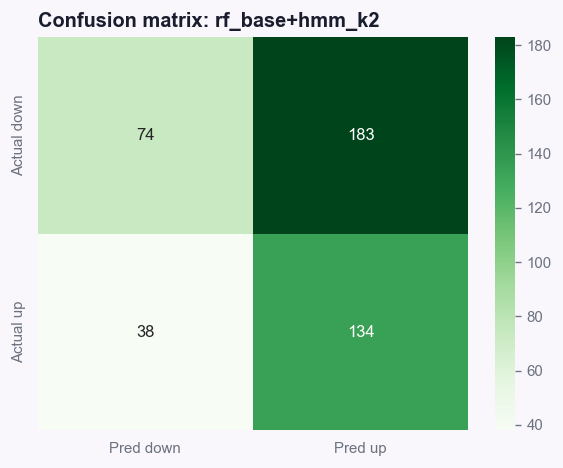

In [18]:
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred down", "Pred up"],
            yticklabels=["Actual down", "Actual up"], ax=ax)
ax.set_title(f"Confusion matrix: {best_model_name}_{best_block_name}_k{best_k}")
plt.tight_layout()
plt.show()

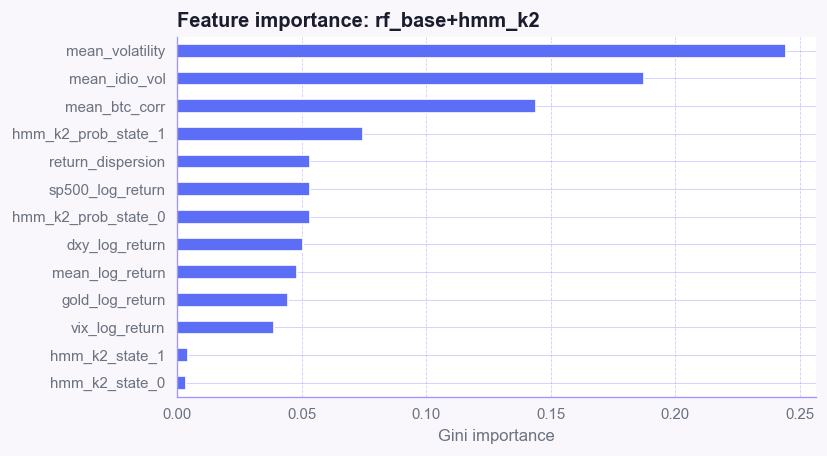

In [19]:
# Tree models expose feature_importances_; logreg uses coef_
model = best["model"]
feat_cols = best["feat_cols"]

if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=feat_cols).sort_values()
    importance_label = "Gini importance"
else:
    importances = pd.Series(np.abs(model.coef_[0]), index=feat_cols).sort_values()
    importance_label = "|coefficient| (scaled)"

fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(importances))))
importances.plot(kind="barh", color="#5B6EF5", ax=ax)
ax.set_title(f"Feature importance: {best_model_name}_{best_block_name}_k{best_k}")
ax.set_xlabel(importance_label)
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Diversification: altcoin and BTC correlation by regime

For each regime of the winning $K$, compute the average per-altcoin Pearson correlation with BTC over the days assigned to that regime. This connects the regime detection back to the projects stated goal: regimes where altcoins decouple from BTC are the ones where holding altcoins genuinely diversifies.

In [20]:
altcoins = ["ETH", "SOL", "XRP", "BNB", "TRX"]
hmm_best_df = hmm_dfs[best_k][["hmm_regime"]]
returns_with_regime = log_returns_df.join(hmm_best_df, how="inner").dropna(subset=["hmm_regime"])

corr_rows = []
for regime, sub in returns_with_regime.groupby("hmm_regime"):
    row = {"regime": int(regime), "n_days": len(sub)}
    for coin in altcoins:
        row[coin] = sub[coin].corr(sub["BTC"])
    row["mean_altcoin_btc_corr"] = float(np.mean([row[c] for c in altcoins]))
    corr_rows.append(row)

corr_by_regime = pd.DataFrame(corr_rows).set_index("regime").sort_index()
print(f"Altcoin↔BTC correlation by regime, K={best_k}:")
corr_by_regime.round(3)

Altcoin↔BTC correlation by regime, K=2:


,n_days,ETH,SOL,XRP,BNB,TRX,mean_altcoin_btc_corr
regime,,,,,,,
0,674,0.820,0.501,0.567,0.656,0.531,0.615
1,1470,0.799,0.679,0.650,0.688,0.530,0.669


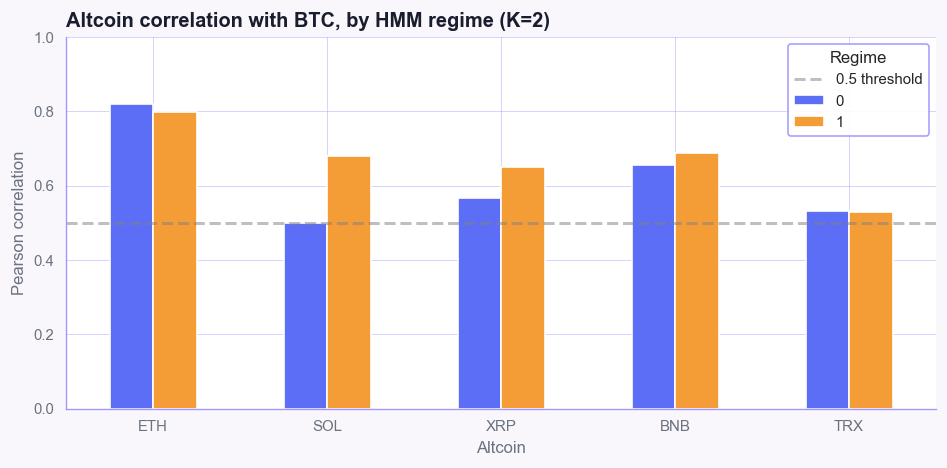

In [21]:
palette = ["#5B6EF5", "#F49D37", "#549F93", "#F76F8E"][:len(corr_by_regime)]

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = corr_by_regime[altcoins]
plot_df.T.plot(kind="bar", ax=ax, color=palette)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="0.5 threshold")
ax.set_title(f"Altcoin correlation with BTC, by HMM regime (K={best_k})")
ax.set_ylabel("Pearson correlation")
ax.set_xlabel("Altcoin")
ax.legend(title="Regime")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Reading the plot.** Compare per-altcoin bars across regimes. The regime with consistently lower bars is the *diversification-friendly* one altcoins move more independently of BTC there, so a portfolio holding them genuinely spreads risk. The high-correlation regime is the one where everything moves together.

Cross-reference with the per-regime metrics table above: a confident BTC-up call from the classifier matters most when it lands in the diversification-friendly regime, because the altcoin payoff is then *not* just a leveraged BTC bet.

## Save predictions for downstream use

The best run's predictions are written to `data/model_outputs/classification_predictions.csv` so notebook 08 (LSTM) can compare or stack against them. The `regime` column is the HMM regime from the winning $K$.

In [22]:
out_df = pd.DataFrame({
    "pred":   best["preds"],
    "proba":  best["proba"],
    "regime": test_data[regime_col].astype(int).to_numpy(),
}, index=y_test.index)
out_df.index.name = "Date"

DATA_MODEL_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
out_df.to_csv(PREDICTIONS_OUTPUT_PATH, index=True)
print(f"Saved best-model predictions to: {PREDICTIONS_OUTPUT_PATH}")
print(f"  k_states = {best_k}, model = {best_model_name}, feature_block = {best_block_name}")
print(f"  n_rows = {len(out_df)}")

with mlflow.start_run(run_name=f"BEST_{best_model_name}_{best_block_name}_k{best_k}"):
    mlflow.log_param("best_k_states", best_k)
    mlflow.log_param("best_model", best_model_name)
    mlflow.log_param("best_block", best_block_name)
    mlflow.log_metric("accuracy", best_acc)
    mlflow.log_metric("f1_macro", best_f1)
    mlflow.log_artifact(str(PREDICTIONS_OUTPUT_PATH))

Saved best-model predictions to: C:\Users\taula\Github\HSLU\DSPRO2\HSLU_FS25_DSPRO2\data\model_outputs\classification_predictions.csv
  k_states = 2, model = rf, feature_block = base+hmm
  n_rows = 429


Limitations:
- 30-day overlapping target windows mean the effective number of independent test observations is much smaller than the row count.
- We're sweeping $K$ on the test set, strictly a hyperparameter search done on held-out data. Reporting the full grid rather than picking the best, is the transparent compromise.
- No hyperparameter search beyond the small manual grid.
- The strategy backtest is short of fees, slippage, and rebalancing cost.